## ML Supervisado: Clasificación Multinomial

El objetivo de este ejercicio es ver como se aplicarían las técnicas de modelado ML supervisdado y tambien experimentar con el balancenado de la muestra

https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009/data  
https://www.kaggle.com/code/silfus/datsetvino


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Seaborn is a Python data visualization library based on matplotlib
import seaborn as sns
%matplotlib inline

#### 0. Importamos los datos

In [2]:
file='../Datasets/winequality-red.csv'
df = pd.read_csv(file, delimiter=',', low_memory=False)
df.shape
#os.getcwd()
print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

#### 1. Análisis de datos

In [3]:
def tipo_variables(df):
    dtypes = df.dtypes
    categorical_cols = []
    numerical_cols = []
    for col, dtype in dtypes.items():
        if pd.api.types.is_numeric_dtype(dtype):
            numerical_cols.append(col)
        else:
            categorical_cols.append(col)
    return numerical_cols, categorical_cols
    
vbles = tipo_variables(df)
num_vbles =vbles[0]
cat_vbles = vbles[1]

print(cat_vbles)
print(num_vbles)

[]
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [4]:
import math
import scipy.stats as stats

In [5]:
def plot_numerical(df):
    numerical_cols=tipo_variables(df)[0]
    a= math.floor(math.sqrt(len(numerical_cols)))+1
    fig, axes = plt.subplots(a, a, figsize=(25,25))
    axes = axes.flatten()
    i = 0
    for t in numerical_cols:
        ax = sns.histplot(data=df, x=t, bins=20,  ax=axes[i])
        i +=1
    plt.show()

def plot_numericalBox(df):
    import math
    import scipy.stats as stats
    
    #a= math.floor(math.sqrt(len(num_vbles)))+1
    num_vbles=tipo_variables(df)[0]
    fig, axes = plt.subplots(math.floor(len(num_vbles)/3)+1,3, figsize=(25,25))
    axes = axes.flatten()
    i = 0
    for i, t in enumerate(num_vbles):
        transformed_data, _ = stats.boxcox(df[t] + 1)  # Se suma 1 para evitar valores negativos/cero
        sns.boxplot(y=transformed_data, ax=axes[i])  # Boxplot en orientación vertical
        axes[i].set_title(f"Box-Cox de {t}")
    plt.tight_layout()
    plt.show()

def plot_categorial(df):
    categorical_cols=tipo_variables(df)[1]
    a= math.floor(math.sqrt(len(categorical_cols)))+1
    #fig, axes = plt.subplots(a, a, figsize=(25,25))
    fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(20,160))
    axes = axes.flatten()
    i = 0
    for t in categorical_cols:
        ax = sns.countplot(x=t, data=df, ax=axes[i])
        i +=1
    plt.show()    
    

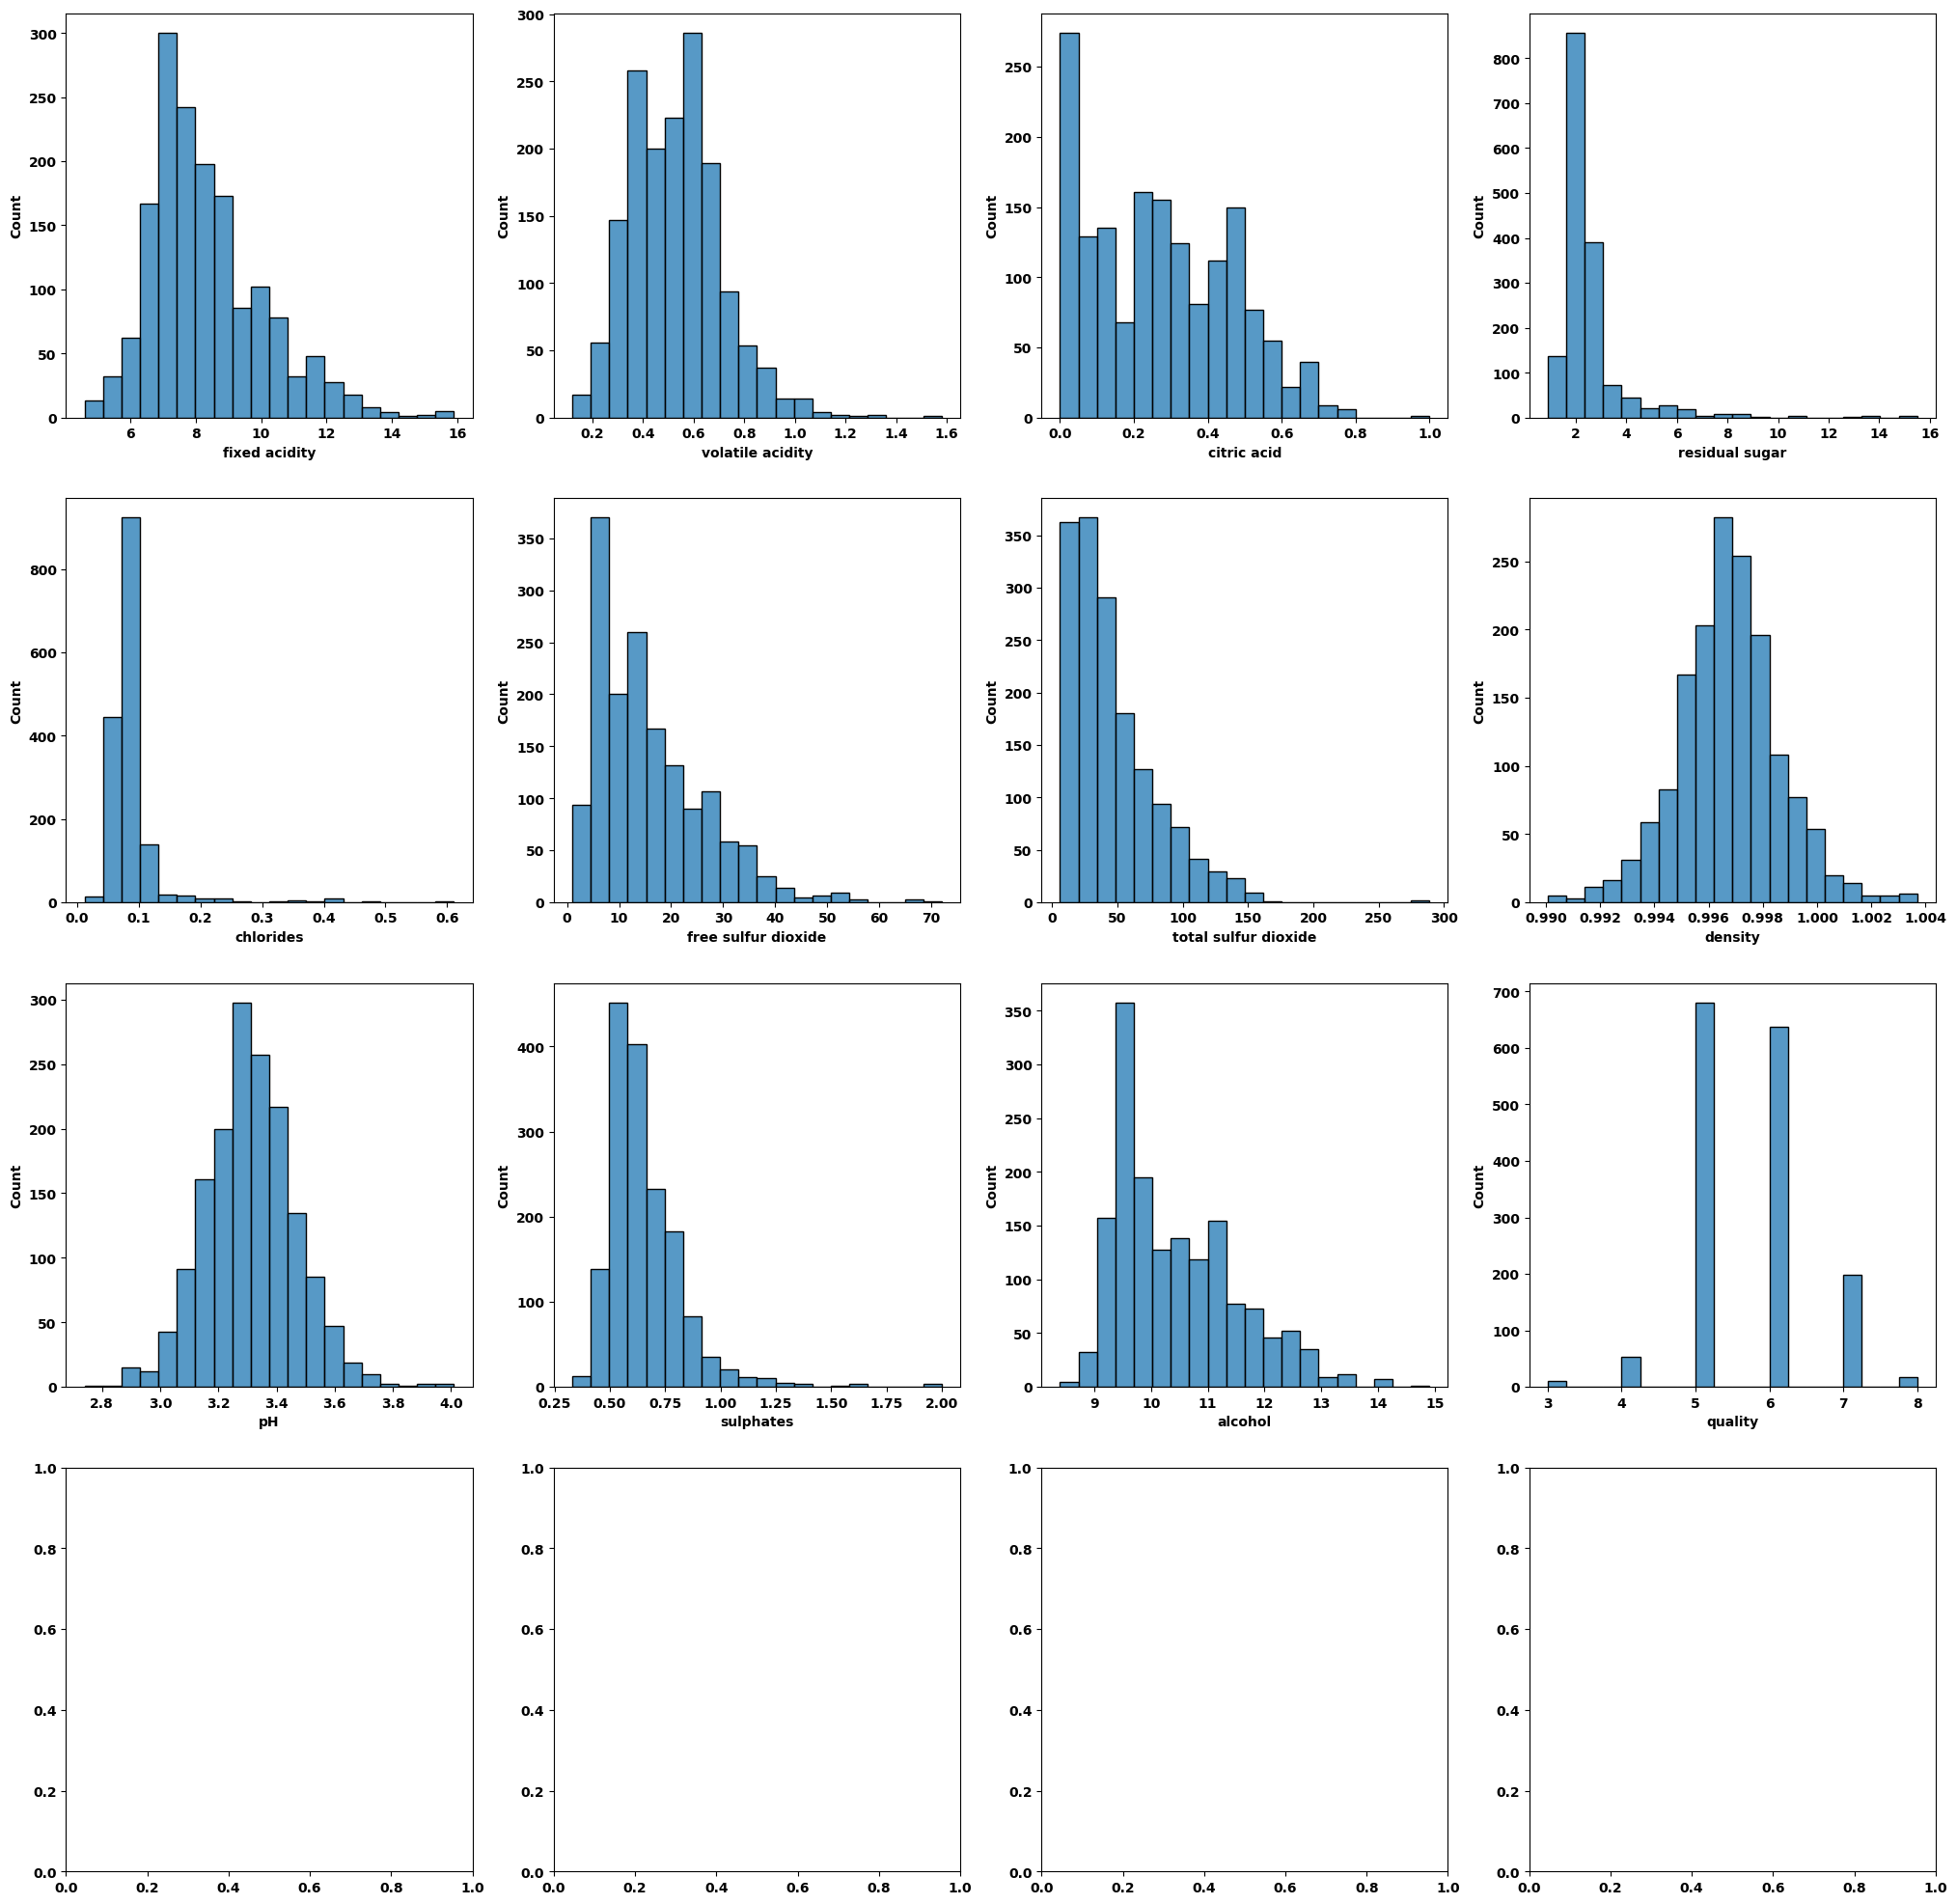

In [6]:
plot_numerical(df)

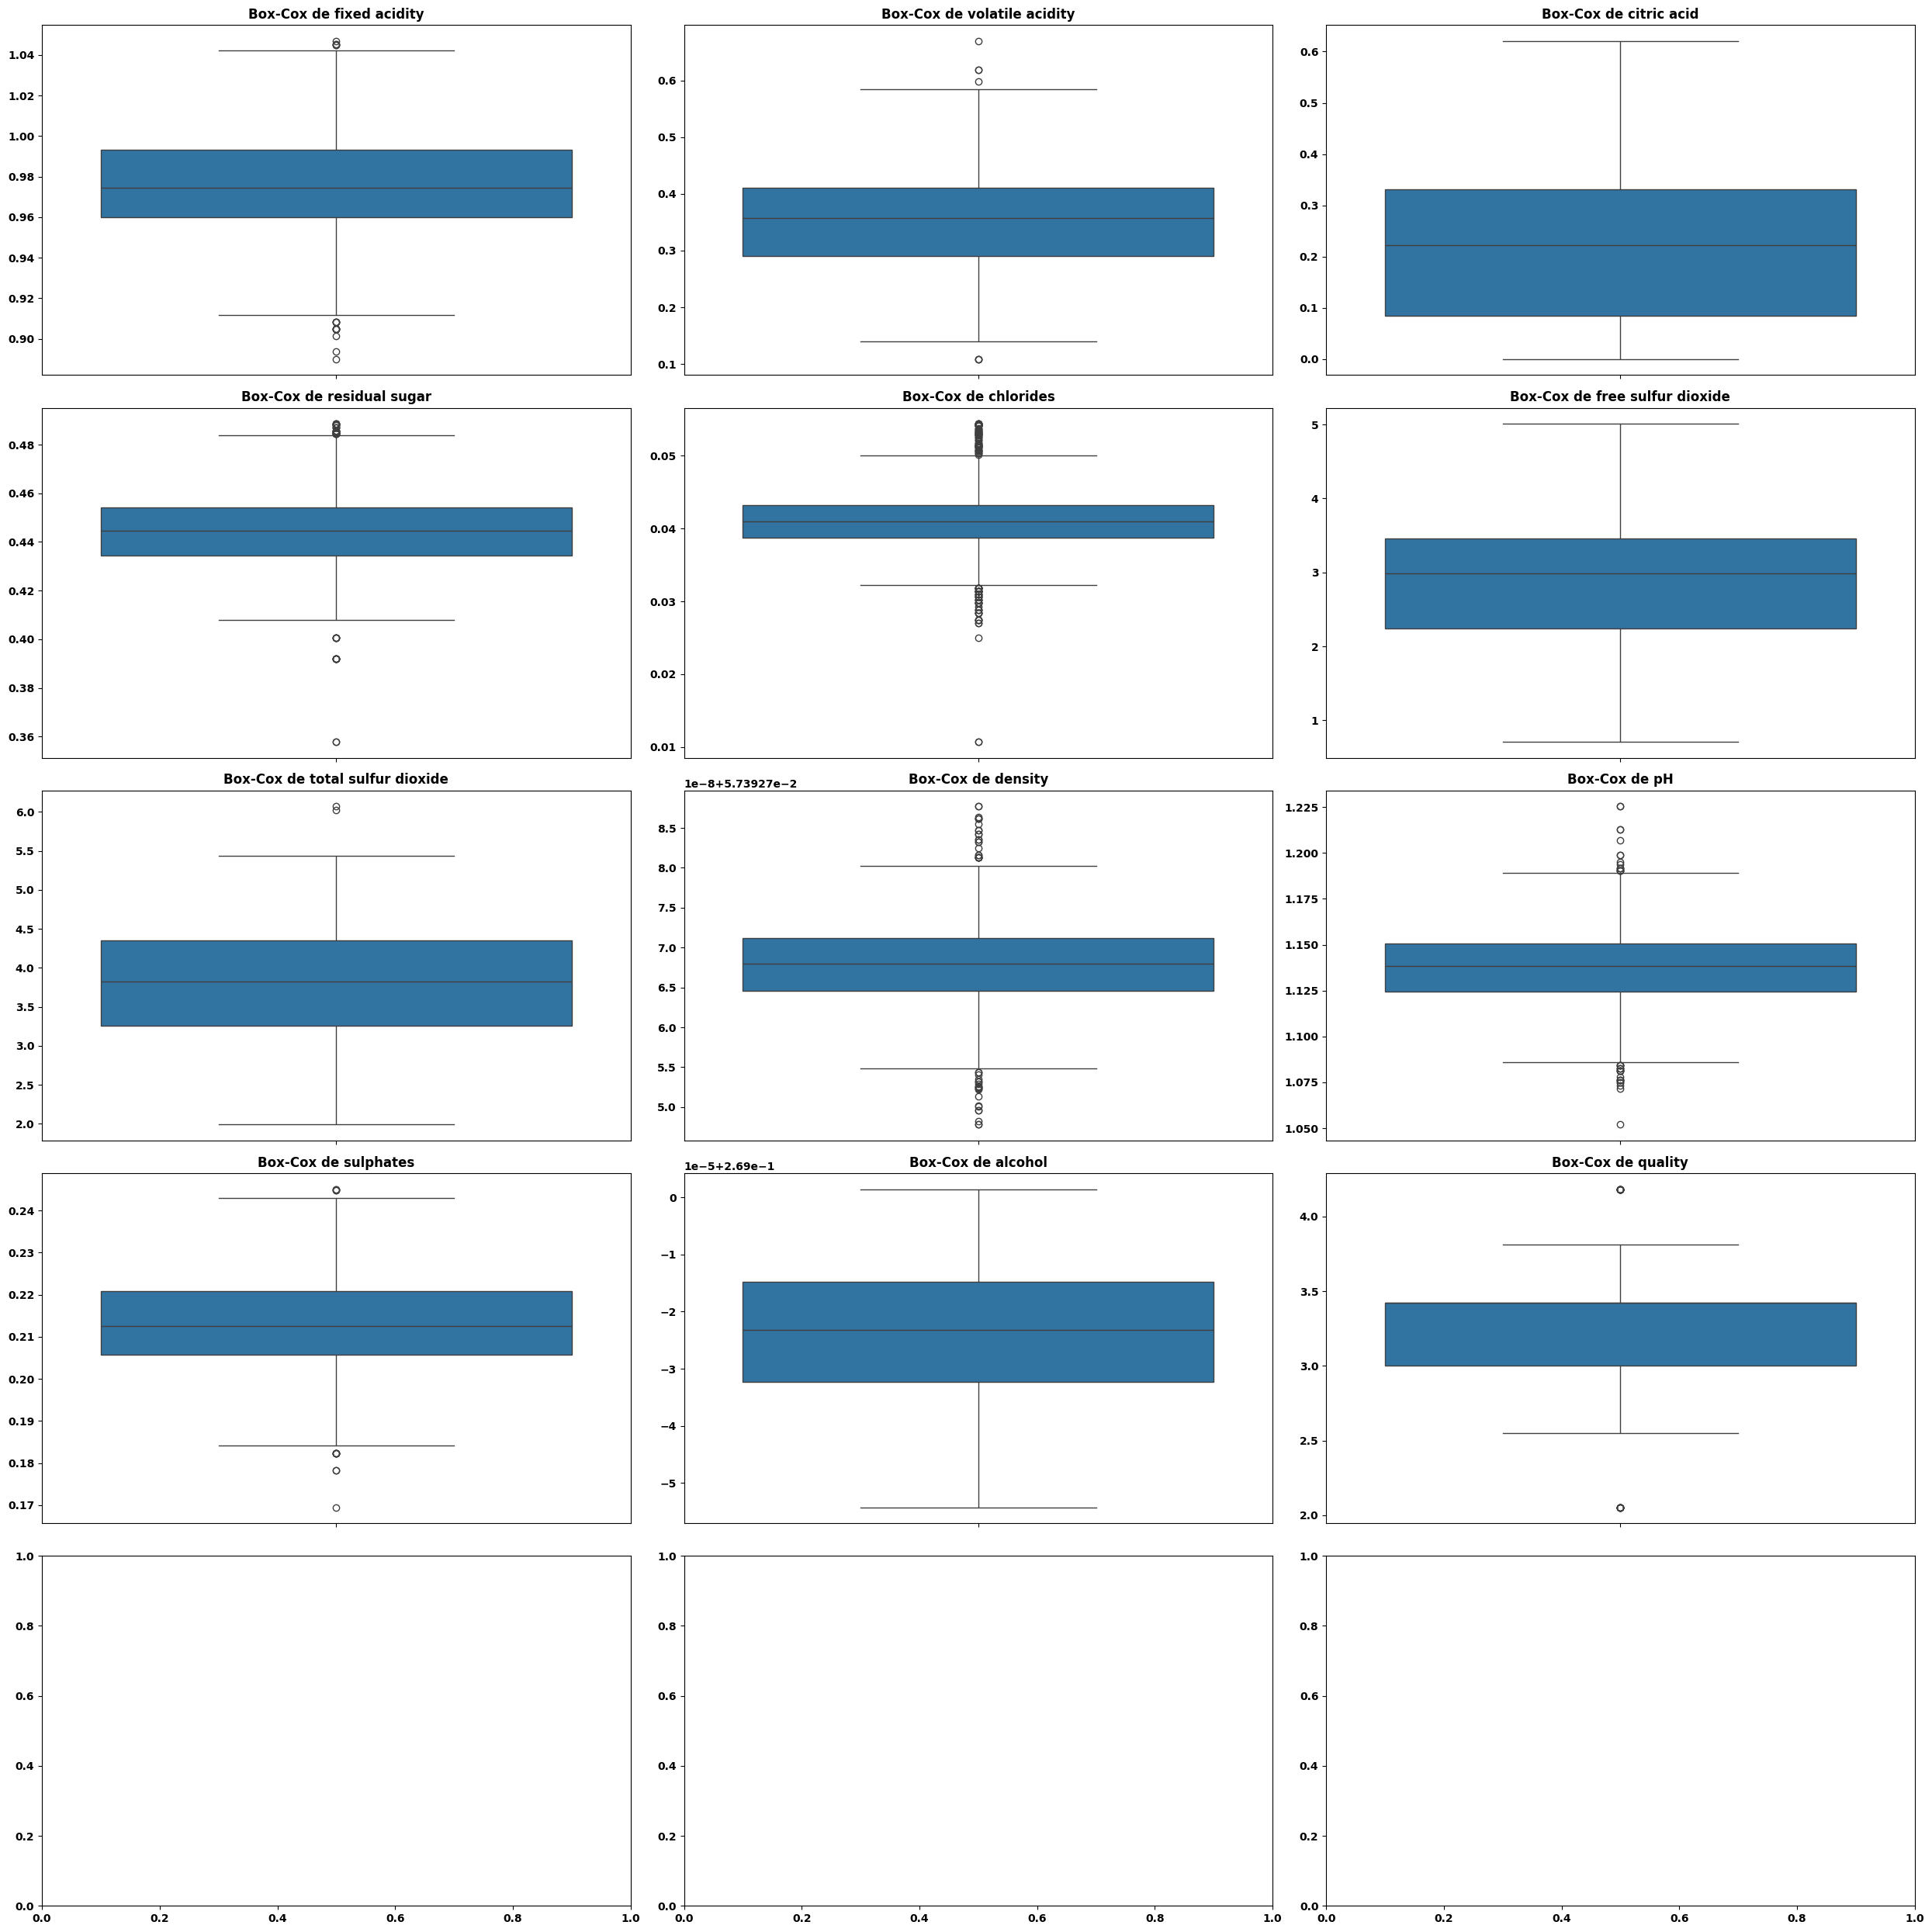

In [7]:
plot_numericalBox(df)

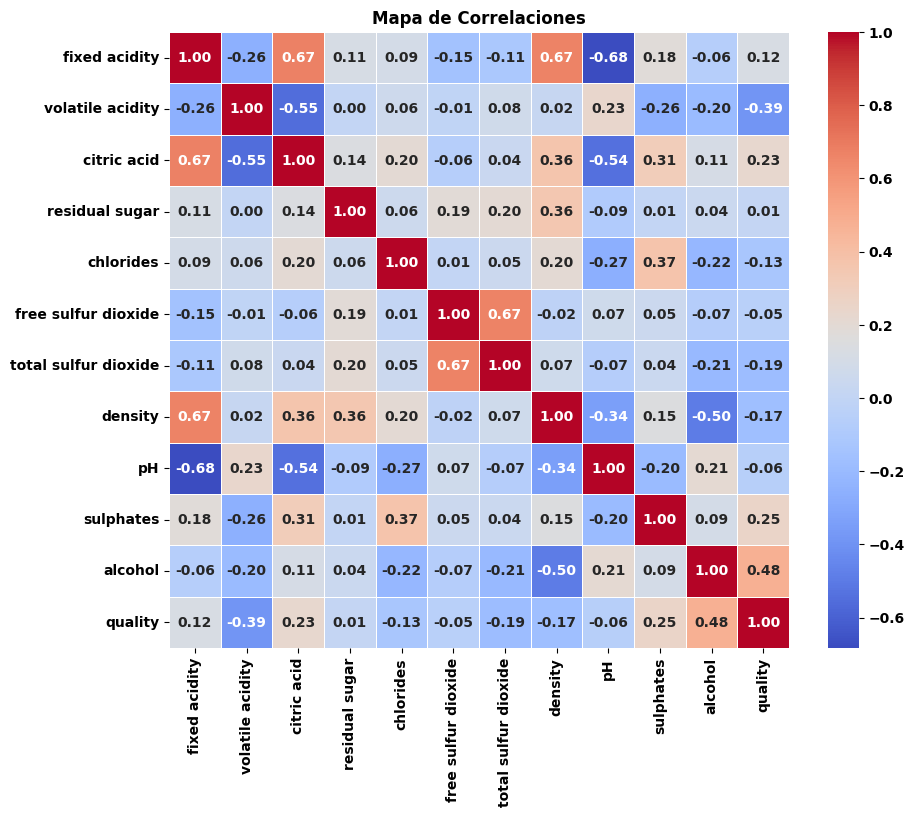

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular matriz de correlación
corr_matrix = df[num_vbles].corr()

#  Generar el heatmap de correlaciones
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Mapa de Correlaciones")
plt.show()

#### 2. Tratamiento de la variable objetivo
La variable objetivo es un variable discreta que toma valores de 0 a 10, y que nos indica la calidad del vino.  Construimos una variable objetivo multinomial que de modo qeu nos clasifique la calidad en alta, media y baja 

In [9]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [10]:
frecuencias = df['quality'].value_counts().sort_index()
frecuencias

quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64

Utilizamos BinDiscretizer

In [11]:
from sklearn.preprocessing import KBinsDiscretizer
enc = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
df['quality_class']=enc.fit_transform(df[['quality']])
df['quality_class'].unique()


array([1., 2., 0.])

In [12]:
pivot = df.pivot_table(
    values='quality',             # Variable numérica
    index='quality_class',          # Variable categórica
    aggfunc=['count', 'max', 'min'] # Funciones agregadas: conteo, máximo y mínimo
)

# Renombrar columnas para claridad
pivot.columns = ['Conteo', 'Máximo', 'Mínimo']
pivot.reset_index(inplace=True)

print(pivot)

   quality_class  Conteo  Máximo  Mínimo
0            0.0      63       4       3
1            1.0    1319       6       5
2            2.0     217       8       7


0: calidad baja: Low  
1: calidad media: Medium  
2: calidad alta: High  

In [13]:
# Define un diccionario de mapeo
mapping = {0: 'Low', 1: 'Medium', 2: 'High'}

# Crea una nueva columna 'class_label' con las etiquetas
df['quality_class'] = df['quality_class'].map(mapping)

In [14]:
frecuencias = df['quality_class'].value_counts()
frecuencias

quality_class
Medium    1319
High       217
Low         63
Name: count, dtype: int64

In [15]:
X=df.drop(columns=['quality', 'quality_class'])
y=df['quality_class']

#### 3. set train & test comprobaciones

A priori ya veíamos que la muestra tiene pocos dato etiquetados como Low. Esto podría ser un problema

In [16]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
valores, recuentos = np.unique(y_test, return_counts=True)

porcentajes = (recuentos / recuentos.sum()) * 100

# Creamos un DataFrame con los resultados
df_resultado = pd.DataFrame({
    'Clase': valores,
    'Frecuencia': recuentos,
    'Porcentaje': porcentajes
})

print(df_resultado)

    Clase  Frecuencia  Porcentaje
0    High          47     14.6875
1     Low          11      3.4375
2  Medium         262     81.8750


In [18]:
valores, recuentos = np.unique(y_train, return_counts=True)

porcentajes = (recuentos / recuentos.sum()) * 100

# Creamos un DataFrame con los resultados
df_resultado = pd.DataFrame({
    'Clase': valores,
    'Frecuencia': recuentos,
    'Porcentaje': porcentajes
})

print(df_resultado)

    Clase  Frecuencia  Porcentaje
0    High         170   13.291634
1     Low          52    4.065676
2  Medium        1057   82.642690


#### 4. Modelo: Árbol de Decision Multinomial

In [19]:
np.unique(df['quality_class'], return_counts=True)[0]

array(['High', 'Low', 'Medium'], dtype=object)

In [20]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dtree = DecisionTreeClassifier(max_depth=4,  max_leaf_nodes=14, random_state=33)
dtree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,33
,max_leaf_nodes,14
,min_impurity_decrease,0.0
,class_weight,None


In [21]:
tree_pred = dtree.predict(X_test)
tree_proba=dtree.predict_proba(X_test)
np.unique(tree_pred, return_counts=True)

(array(['High', 'Medium'], dtype=object), array([ 33, 287]))

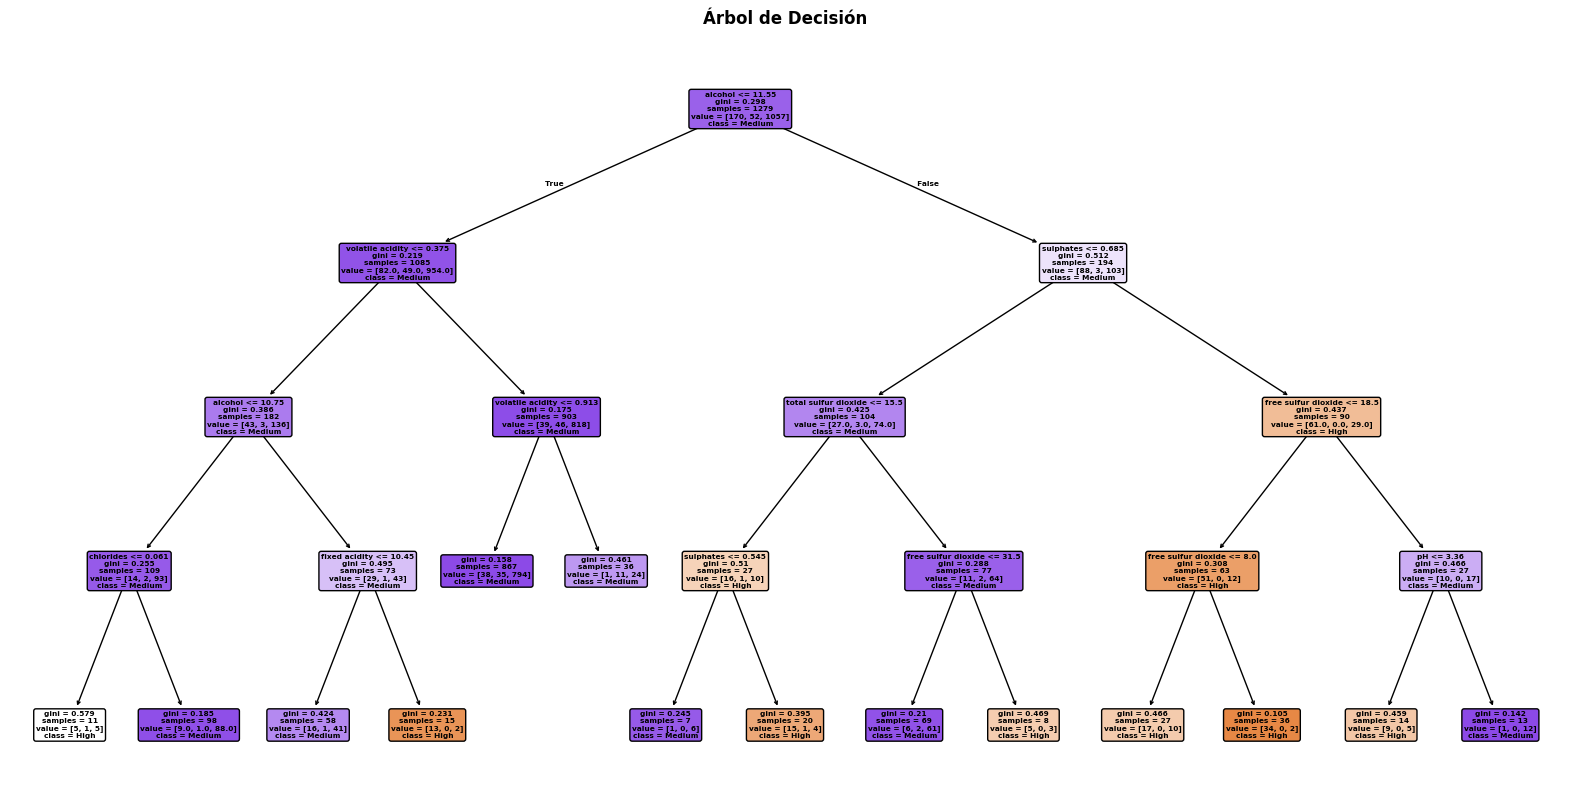

In [22]:
plt.figure(figsize=(20,10))
plot_tree(dtree,
          feature_names=X.columns,
          class_names=np.unique(df['quality_class'], return_counts=True)[0],
          filled=True,
          rounded=True)
plt.title("Árbol de Decisión")
plt.show()

In [23]:
np.unique(tree_pred, return_counts=True)[0]

array(['High', 'Medium'], dtype=object)

#### 4.2 Evaluación del modelo
Es interesante ver cómo construimos la curva ROC para el caso multinomial. Aquí se enfrenta cada una de clases frente al resto: One vs Rest  

In [24]:
def confusion_matrix(y_test, predictions):
    from sklearn.metrics import confusion_matrix
    labels = np.unique(y_test, return_counts=True)[0]
    #cm = confusion_matrix(y_test, predictions, labels=[1, 0])
    cm = confusion_matrix(y_test, predictions, labels = labels)
    # Mostrar la matriz de confusión
    #print("Matriz de Confusión:")
    #print(cm)

    import seaborn as sns
    import matplotlib.pyplot as plt

    #sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Clase 1", "Clase 0"], yticklabels=["Clase 1", "Clase 0"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels, yticklabels=labels)
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.title("Matriz de Confusión")
    plt.show()
    return

def classification_report(y_test, predictions):
    from sklearn.metrics import classification_report
    report = classification_report(y_test,predictions, output_dict=True)
    # Convertir el diccionario en un DataFrame de pandas
    df_report = pd.DataFrame(report).transpose()
    print(classification_report(y_test,predictions))
    return df_report

    
def ROC_Curve (y_test, predictions):
    from sklearn.metrics import roc_auc_score
    from sklearn.metrics import roc_curve

    # Calcular ROC-AUC
    roc_auc = roc_auc_score(y_test, predictions)
    print(f"ROC-AUC: {roc_auc:.2f}")

# Calcular los valores para la curva ROC
    fpr, tpr, thresholds = roc_curve(y_test, predictions)

# Graficar la curva ROC
    plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.2f})")
    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")  # Línea diagonal para referencia
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()
    return roc_auc

from sklearn.preprocessing import label_binarize
import numpy as np

def binarize_labels(y, classes=None):
    """
    Binariza etiquetas categóricas automáticamente.
    
    Parámetros:
        y: list, array o iterable de etiquetas.
        classes: opcional, si se quiere forzar un orden específico.
        
    Retorna:
        - Matriz binarizada
        - Lista de clases utilizadas (ordenadas)
    """
    if classes is None:
        classes = sorted(np.unique(y))  # detecta clases automáticamente y las ordena alfabéticamente
    binary = label_binarize(y, classes=classes)
    return binary, classes


def ROC_curve_multi(y_test, pred_proba, class_labels=None):
    import matplotlib.pyplot as plt
    from sklearn.metrics import roc_curve, auc
    from sklearn.preprocessing import label_binarize
    import numpy as np
    """
    Traza las curvas ROC One-vs-Rest para problemas multiclase.

    Parámetros:
    - y_test: array 1D con clases verdaderas (no binarizadas)
    - pred_proba: array 2D con probabilidades por clase (shape: [n_samples, n_clases])
    - class_labels: lista opcional con los nombres de las clases (por defecto: 0, 1, 2, ...)
    """
    # Binarizar las clases verdaderas
    n_classes = pred_proba.shape[1]
    #y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))
    y_test_bin, used_classes = binarize_labels(y_test)
    plt.figure(figsize=(8, 6))
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], pred_proba[:, i])
        roc_auc = auc(fpr, tpr)
        label = f"{used_classes[i]}"
        plt.plot(fpr, tpr, label=f"{label} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', label='Azar')
    plt.xlabel('Tasa de falsos positivos')
    plt.ylabel('Tasa de verdaderos positivos')
    plt.title('Curvas ROC Multiclase (One-vs-Rest)')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()



def kappa_y_mcc(y_test, predictions):
    from sklearn.metrics import cohen_kappa_score, matthews_corrcoef
    # Calcular el índice Kappa
    kappa = cohen_kappa_score(y_test,predictions)
    mcc = matthews_corrcoef(y_test, predictions)
    print('kappa:' ,kappa, 'mcc:', mcc) 
    return kappa, mcc

def metricas(y_test, y_pred, y_pred_proba, tag):
    confusion_matrix(y_test, y_pred)
    df_report = classification_report(y_test, y_pred)
    roc_auc=ROC_Curve(y_test, y_pred_proba)
    kappa, mcc = kappa_y_mcc(y_test, y_pred)
    return tag, roc_auc, df_report.loc['1', 'precision'], df_report.loc['1', 'recall'], df_report.loc['1', 'f1-score'],  df_report.loc['accuracy', 'f1-score'], kappa, mcc


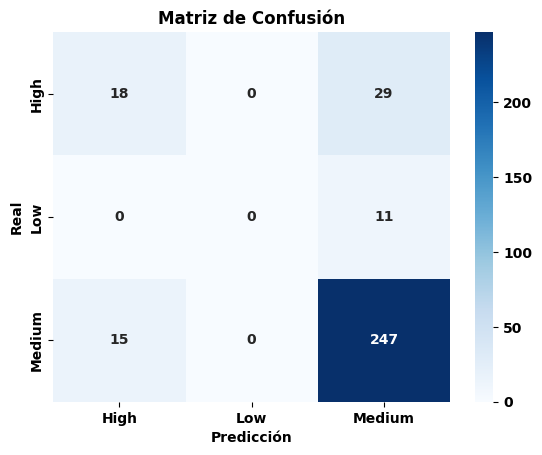

c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

              precision    recall  f1-score   support

        High       0.55      0.38      0.45        47
         Low       0.00      0.00      0.00        11
      Medium       0.86      0.94      0.90       262

    accuracy                           0.83       320
   macro avg       0.47      0.44      0.45       320
weighted avg       0.78      0.83      0.80       320

kappa: 0.3139738842330929 mcc: 0.3301475475507694


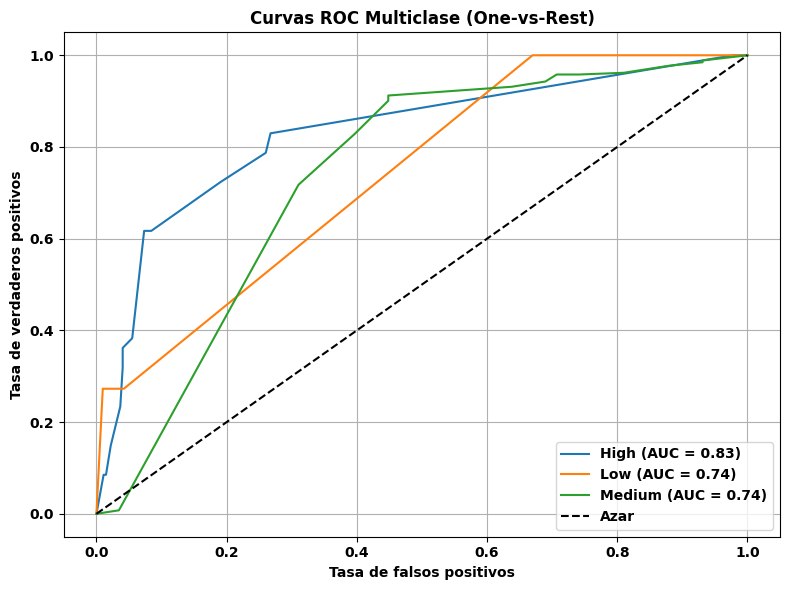

In [25]:
confusion_matrix(y_test,tree_pred)
classification_report(y_test,tree_pred)
kappa_y_mcc(y_test,tree_pred)
ROC_curve_multi(y_test, tree_proba)

#### 5. Ejemplo de balanceado: árbol de decisión

Veíamos antes que la etiqueta "Low" quedaba muy poco poblada. Vemos ahora técnicas para "rellenar" la categoría "Low"

In [26]:
pip install imbalanced-learn


   ---------------------------------------- 0/2 [sklearn-compat]
   ---------------------------------------- 0/2 [sklearn-compat]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn]
   -------------------- ------------------- 1/2 [imbalanced-learn

**SMOTE** (Synthetic Minority Over-sampling Technique )  
Genera valores sinteticos para "rellenar" clases  
* **'auto' (por defecto)***	Reequilibra todas las clases menos la mayoritaria.
* **'minority'**	Solo sobremuestrea la clase minoritaria.
* **'not minority'**	Sobremuestrea todas las clases excepto la minoritaria.
* **'not majority'**	'not majority'	Sobremuestrea todas las clases excepto la mayoritaria.
* **'all'**		Sobremuestrea todas las clases para igualar la más frecuente.
* **float	0.5**	Solo para clasificación binaria. Indica el ratio deseado entre minoritaria y mayoritaria. Ej: 0.5 = minoritaria tendrá la mitad de muestras que la mayoritaria.
* **dict	{0: 500, 1: 500}**	Especifica el número exacto de muestras deseadas por clase.
* **callable**	lambda y: {...}	Función que recibe y y devuelve un diccionario como el anterior. Útil para lógica personalizada.

In [27]:
from imblearn.over_sampling import SMOTE,SMOTEN 

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Aplicar SMOTE para sobremuestrear las clases minoritarias (funciona en multiclase)
sm = SMOTE(random_state=42, sampling_strategy='all')
#sm = SMOTE(random_state=42, sampling_strategy='minority')

X_res, y_res = sm.fit_resample(X_train, y_train)



Sobreemuestreamos todas las clase excepto la mayoritaria

In [28]:
valores, recuentos = np.unique(y_res, return_counts=True)

porcentajes = (recuentos / recuentos.sum()) * 100

# Creamos un DataFrame con los resultados
df_resultado = pd.DataFrame({
    'Clase': valores,
    'Frecuencia': recuentos,
    'Porcentaje': porcentajes
})

print(df_resultado)

    Clase  Frecuencia  Porcentaje
0    High         986   33.333333
1     Low         986   33.333333
2  Medium         986   33.333333


#### 5.1 Modelo de árbol de decision con las clases balanceadas

In [29]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
dtree = DecisionTreeClassifier(max_depth=4,  max_leaf_nodes=14, random_state=33)
dtree.fit(X_res,y_res)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,33
,max_leaf_nodes,14
,min_impurity_decrease,0.0
,class_weight,None


In [30]:
tree_pred = dtree.predict(X_test)
tree_proba=dtree.predict_proba(X_test)
np.unique(tree_pred, return_counts=True)

(array(['High', 'Low', 'Medium'], dtype=object), array([108,  75, 217]))

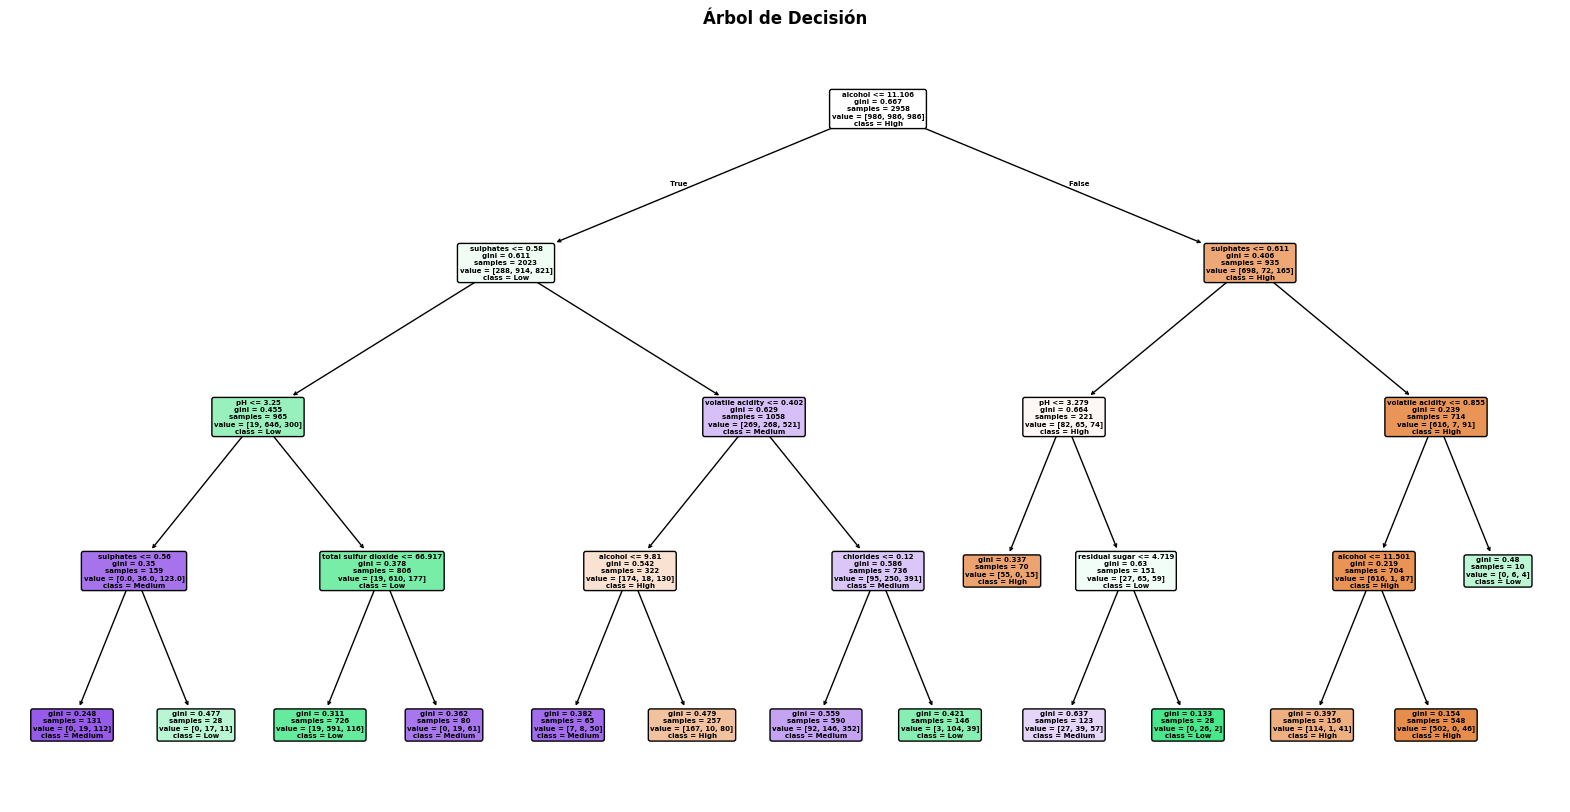

In [31]:
plt.figure(figsize=(20,10))
plot_tree(dtree,
          feature_names=X.columns,
          class_names=np.unique(y_train, return_counts=True)[0],
          filled=True,
          rounded=True)
plt.title("Árbol de Decisión")
plt.show()

#### 5.2 Evaluamos el modelo

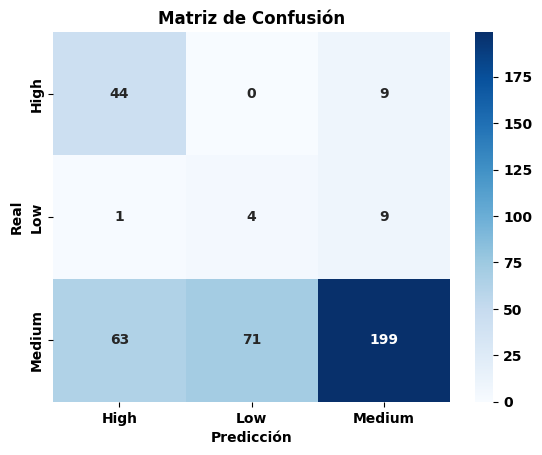

              precision    recall  f1-score   support

        High       0.41      0.83      0.55        53
         Low       0.05      0.29      0.09        14
      Medium       0.92      0.60      0.72       333

    accuracy                           0.62       400
   macro avg       0.46      0.57      0.45       400
weighted avg       0.82      0.62      0.68       400

kappa: 0.24411782869140985 mcc: 0.2976728216675876


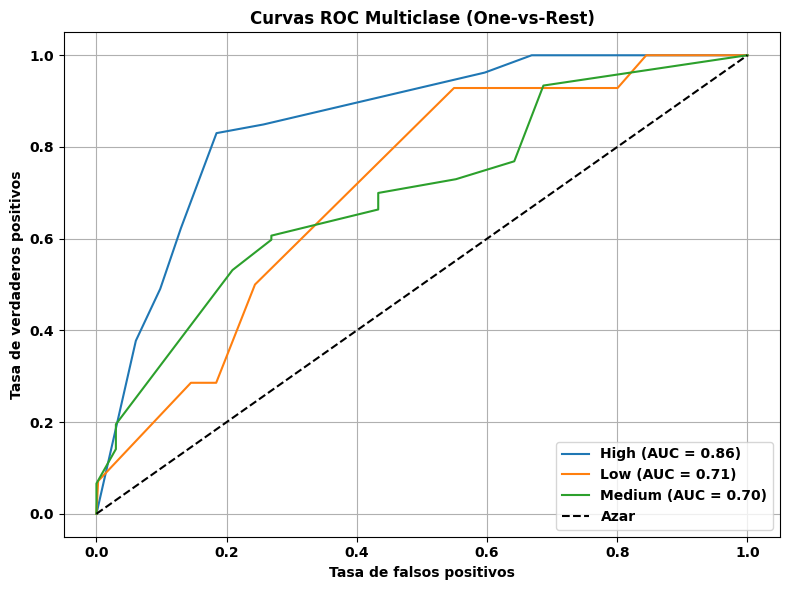

In [32]:
confusion_matrix(y_test,tree_pred)
classification_report(y_test,tree_pred)
kappa_y_mcc(y_test,tree_pred)
ROC_curve_multi(y_test, tree_proba)

#### 6. Modelo KNN con clases balanceadas

In [33]:
# sin balancear 
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_res, y_res)
knn_pred = knn.predict(X_test)
knn_proba = knn.predict_proba(X_test)

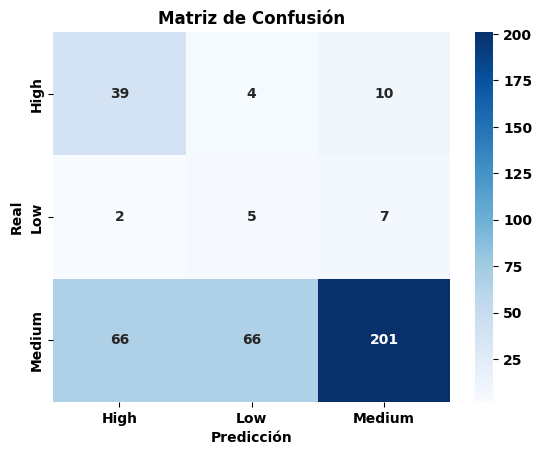

              precision    recall  f1-score   support

        High       0.36      0.74      0.49        53
         Low       0.07      0.36      0.11        14
      Medium       0.92      0.60      0.73       333

    accuracy                           0.61       400
   macro avg       0.45      0.57      0.44       400
weighted avg       0.82      0.61      0.68       400

kappa: 0.2315795996777592 mcc: 0.28173165050559


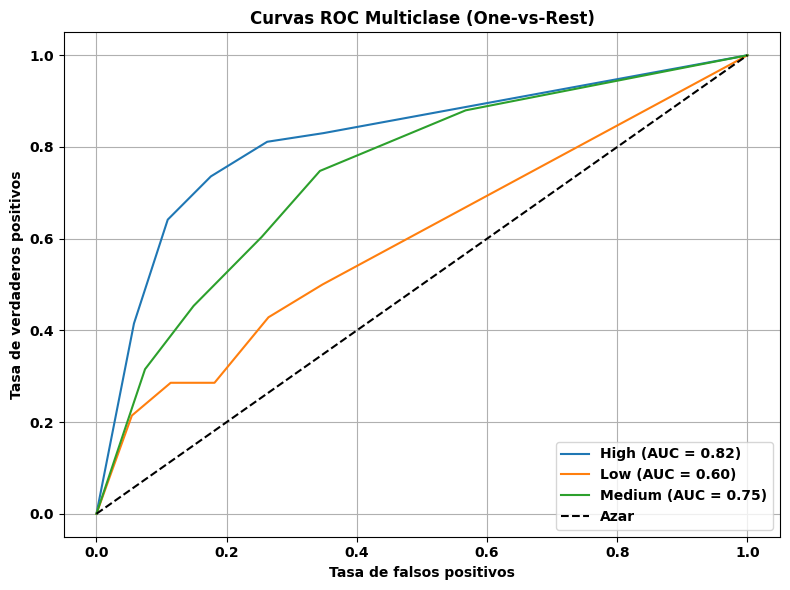

In [34]:
confusion_matrix(y_test,knn_pred)
classification_report(y_test,knn_pred)
kappa_y_mcc(y_test,knn_pred)
ROC_curve_multi(y_test, knn_proba)

#### 7. Naive Bayes

In [35]:
from sklearn.naive_bayes import GaussianNB 
gnb = GaussianNB()
gnb.fit(X_res, y_res)
gnb_pred = gnb.predict(X_test)
gnb_proba = gnb.predict_proba(X_test)

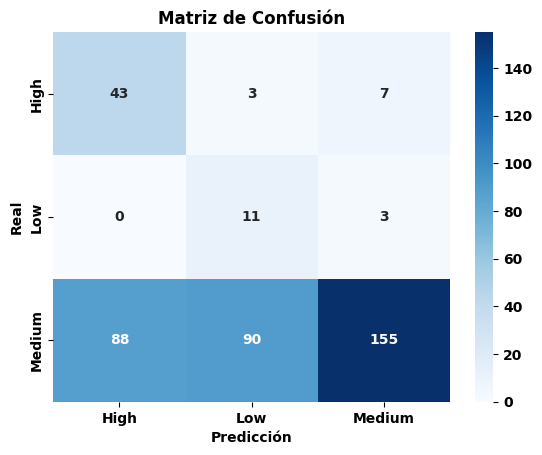

              precision    recall  f1-score   support

        High       0.33      0.81      0.47        53
         Low       0.11      0.79      0.19        14
      Medium       0.94      0.47      0.62       333

    accuracy                           0.52       400
   macro avg       0.46      0.69      0.43       400
weighted avg       0.83      0.52      0.59       400

kappa: 0.20956795232577385 mcc: 0.29140598560000924


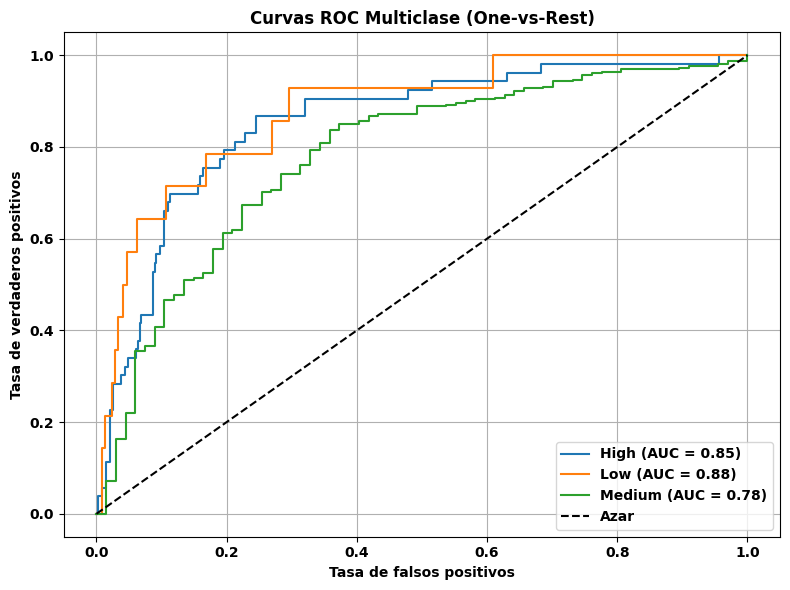

In [36]:
confusion_matrix(y_test,gnb_pred)
classification_report(y_test,gnb_pred)
kappa_y_mcc(y_test,gnb_pred)
ROC_curve_multi(y_test, gnb_proba)

#### 8. XG Boost

Hay que tener cuidado porequer no admite clases como string, hay que convertirlas a numerico

In [37]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y_res) 

In [38]:
from xgboost import XGBClassifier
xgb = XGBClassifier(
    objective='multi:softprob',  # para obtener probabilidades por clase
    num_class=3,                 # número de clases
    eval_metric='mlogloss',
    n_estimators=1000,
    use_label_encoder=False,
    random_state=42
)

xgb.fit(X_res, y_encoded)

c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv2\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:58:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [39]:
xgb_pred = le.inverse_transform(xgb.predict(X_test)) # deshacemnos la transformación para poder comparar
xgb_proba = xgb.predict_proba(X_test)
xgb_pred

array(['Medium', 'Medium', 'Medium', 'Low', 'Medium', 'Medium', 'Medium',
       'Medium', 'High', 'Medium', 'High', 'Low', 'Medium', 'Medium',
       'Medium', 'High', 'Medium', 'Medium', 'High', 'Medium', 'Medium',
       'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium',
       'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium',
       'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'High',
       'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'High',
       'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Low', 'High',
       'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium',
       'Medium', 'Medium', 'Medium', 'Medium', 'High', 'Medium', 'High',
       'Medium', 'High', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium',
       'Medium', 'Medium', 'High', 'Medium', 'Medium', 'High', 'Medium',
       'High', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium', 'Medium',
       'High', 'Medium', 'High', 'Low', 'Medium', 'Medium', 'Med

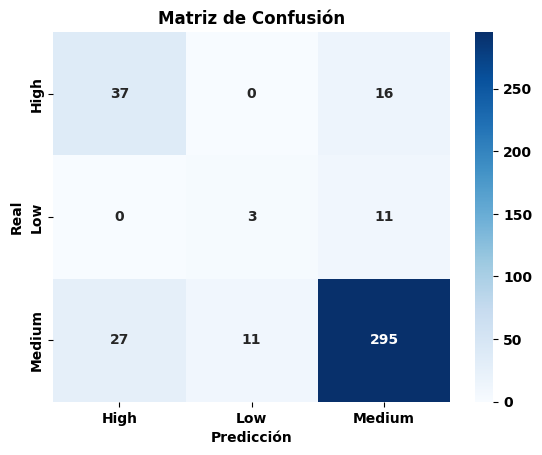

              precision    recall  f1-score   support

        High       0.58      0.70      0.63        53
         Low       0.21      0.21      0.21        14
      Medium       0.92      0.89      0.90       333

    accuracy                           0.84       400
   macro avg       0.57      0.60      0.58       400
weighted avg       0.85      0.84      0.84       400

kappa: 0.47139429919082665 mcc: 0.47341851417364955


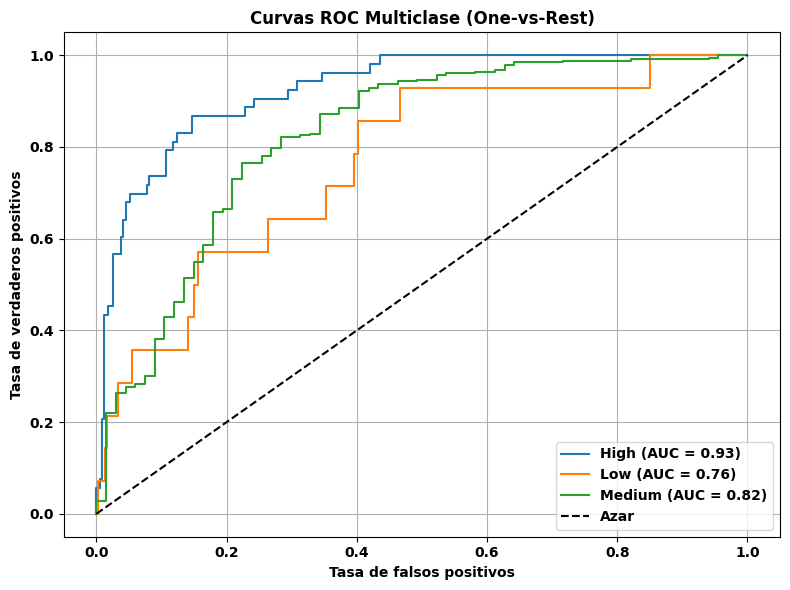

In [40]:
confusion_matrix(y_test,xgb_pred)
classification_report(y_test,xgb_pred)
kappa_y_mcc(y_test,xgb_pred)
ROC_curve_multi(y_test, xgb_proba)

#### 9. Optimizacion de XGBoost con Optuna

In [41]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.model_selection import train_test_split

def objective(trial):
    params = {
        'objective': 'multi:softprob',  # Correcto para clasificación multiclase
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 5),
        'use_label_encoder': False,
        'eval_metric': 'mlogloss',  # Cambiado a 'mlogloss' para clasificación multiclase
    }

    model = XGBClassifier(**params)
    model.fit(X_res, y_encoded)
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    #auc = roc_auc_score(y_test, y_pred_proba)
    recall=recall_score(y_test, le.inverse_transform(model.predict(X_test)), average='macro')
    
    return recall


study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=200)

# Mejor conjunto de hiperparámetros encontrados
print(f"Mejores parámetros: {study.best_params}")
print(f"Mejor recall obtenido: {study.best_value:.4f}")

c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-03-16 20:58:42,200] A new study created in memory with name: no-name-2d1fd912-3687-45a3-9cf7-af8717f94851
c:\Users\Oscar\OneDrive - FM4\Escritorio\EVOLVE\Data Science\.venv2\Lib\site-packages\xgboost\training.py:199: UserWarning: [20:58:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
[I 2026-03-16 20:58:44,593] Trial 0 finished with value: 0.6556219292068348 and parameters: {'learning_rate': 0.11861663446573512, 'n_estimators': 481, 'max_depth': 12, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'reg_alpha': 0.290418060

Mejores parámetros: {'learning_rate': 0.010065635937481278, 'n_estimators': 408, 'max_depth': 5, 'subsample': 0.5109397702419185, 'colsample_bytree': 0.5448386018593198, 'gamma': 3.6291775971739395, 'reg_alpha': 4.042749419291511, 'reg_lambda': 3.303872006792592}
Mejor recall obtenido: 0.7483


In [42]:
best_params = study.best_params
best_model = XGBClassifier(**best_params)
best_model.fit(X_res, y_encoded)
xgb1_pred  = le.inverse_transform(best_model.predict(X_test))
xgb1_pred_proba = best_model.predict_proba(X_test)

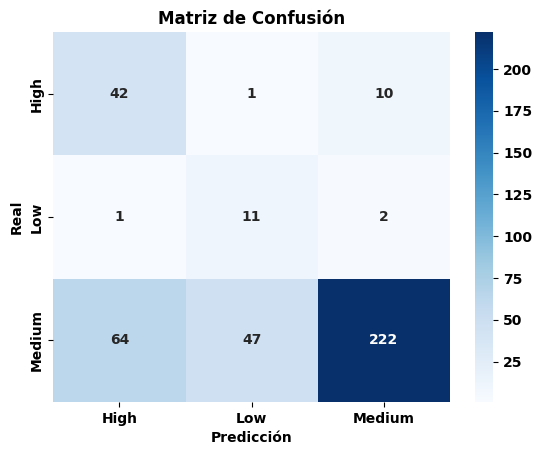

              precision    recall  f1-score   support

        High       0.39      0.79      0.53        53
         Low       0.19      0.79      0.30        14
      Medium       0.95      0.67      0.78       333

    accuracy                           0.69       400
   macro avg       0.51      0.75      0.54       400
weighted avg       0.85      0.69      0.73       400

kappa: 0.33845807808840844 mcc: 0.39642520180540836


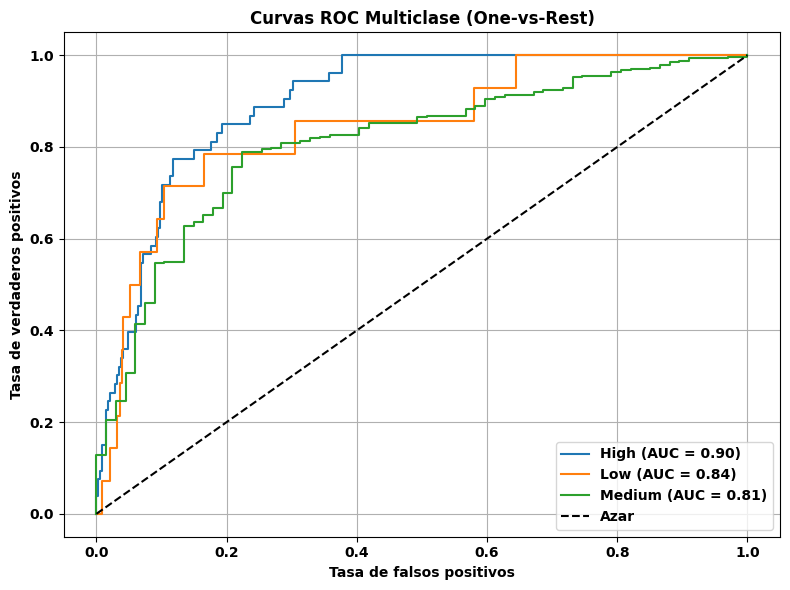

In [43]:
confusion_matrix(y_test,xgb1_pred)
classification_report(y_test,xgb1_pred)
kappa_y_mcc(y_test,xgb1_pred)
ROC_curve_multi(y_test, xgb1_pred_proba)

Cuando pedimos que optimice recall, para que clases se optimiza?